# Example 2: Wasserstein Ambiguity

### Imports

Imports all required libraries for:
- numerical computation (`numpy`)
- optimization (`cvxpy`)
- plotting (`matplotlib`)
- utilities (`itertools`, `time`)


In [34]:
import itertools
import time
import numpy as np
import cvxpy as cp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker



### Parameters

Defines all model, ambiguity, discretization, and algorithm parameters used in the experiment.

- Specifies the **market dynamics** (drift, volatility range, horizon)
- Sets the **Wasserstein radius** $\rho$
- Discretizes the **action space** and **wealth space**
- Configures **actor–critic hyperparameters**

Also fixes randomness for reproducibility.


---

#### Outputs
- Model parameters: $\mu$, $\sigma \in [\sigma_{\min}, \sigma_{\max}]$, $T$, $S_0$, $K$
- Ambiguity size: $\rho$
- Discrete grids: $A_{\text{grid}}$, $W_{\text{grid}}$
- Algorithm settings: iterations, step sizes, Monte Carlo sample sizes
- Dimensions: $|A| = \texttt{NA}$, $|W| = \texttt{NW}$

In [35]:
# ═══════════════════════════════════════════════════════════════════════════════
# PARAMETERS
# ═══════════════════════════════════════════════════════════════════════════════

np.random.seed(0)

# ── Market model ─────────────────────────────────────────────────────────────
MU        = 0.02
SIGMA     = 0.10
T         = 3
K_STRIKE  = 1.05
S0        = 1.0

# ── Ambiguity set ─────────────────────────────────────────────────────────────
N_PATHS   = 70       
RHO       = 0.08

# ── MDP discretisation ───────────────────────────────────────────────────────
A_GRID = np.linspace(-2.0, 2.0, 10)
W_GRID = np.linspace(-0.3, 1.8, 28)

# ── Actor-critic hyper-parameters ────────────────────────────────────────────
N_AC_ITERS   = 20
ETA_ACTOR    = 0.05    # policy-gradient step size           [tune: 0.01–0.20]
N_MC_GRAD    = 100     # MC samples for critic gradient      [generous; cheap]
N_MC_Q       = 60      # MC samples per (state, action) for Q  [tune: 20–150]
N_FW_STEPS   = 8       # Frank-Wolfe inner iterations        [tune: 4–15]
FW_STEP_SIZE = 0.25    # alpha_k for Frank-Wolfe             [tune: 0.1–0.5]
POLICY_EMA   = 0.15    # EMA weight on new iterate           [tune: 0.05–0.30]

NA = len(A_GRID)
NW = len(W_GRID)

### Data Generation

Generates all possible sample paths of the price process and computes associated quantities.

- Enumerates all combinations of:
  - volatility levels $\sigma$
  - binary innovations $\varepsilon_t \in \{-1,+1\}$
- Constructs price paths using:
  $$
  S_{t+1} = S_t + \mu + \sigma \varepsilon_{t+1}
  $$
- Computes:
  - terminal payoffs $\zeta = (S_T - K)^+$
  - price increments $\Delta S_t$
- Initializes the empirical distribution as uniform:
  $$
  \xi_0 = \left(\tfrac{1}{N}, \dots, \tfrac{1}{N}\right)
  $$

---

####  Inputs
- Model parameters: $\mu$, $\sigma_{\min}$, $\sigma_{\max}$, $T$, $S_0$, $K$
- Discretization: $N_{\sigma}$

---

#### Outputs
- `paths`: all simulated price paths
- $N$: number of paths
- `payoffs`: terminal payoff for each path
- `ds`: price increments $\Delta S$
- $\xi_0$: empirical (uniform) distribution over paths

In [36]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA  
# ═══════════════════════════════════════════════════════════════════════════════

def generate_paths(N):
    paths = []

    # discrete shock set (NOT just ±1)
    shock_grid = np.array([-2, -1, 0, 1, 2]) * 0.05

    for _ in range(N):
        s = [S0]

        for t in range(T):
            shock = np.random.choice(shock_grid)
            s.append(s[-1] + MU + shock)

        paths.append(s)

    return np.array(paths)

paths = generate_paths(N_PATHS)
N = len(paths)

ds      = np.diff(paths, axis=1)
payoffs = np.maximum(paths[:, -1] - K_STRIKE, 0.0)
xi_0    = np.ones(N) / N

print(f"N = {N} paths")
print(f"Call payoff range: [{payoffs.min():.4f}, {payoffs.max():.4f}]"
      f"  mean = {payoffs.mean():.4f}")
print(f"|A_GRID|={NA}  |W_GRID|={NW}")

N = 70 paths
Call payoff range: [0.0000, 0.3100]  mean = 0.0566
|A_GRID|=10  |W_GRID|=28


### Compute and store path distances
Constructs the **Wasserstein distance structure** and the **information (history) structure** of the problem.

---

### 1. Path distance matrix

Computes pairwise distances:
$$
D_{ij} = \sum_{t=0}^T |s_t^{(i)} - s_t^{(j)}|
$$

This defines the cost used in the Wasserstein constraint.

---

### 2. Consistent sets (history nodes)

For each path $i$ and time $t$, defines:
$$
C(i,t) = \{ j : (S_0,\dots,S_t)^{(j)} = (S_0,\dots,S_t)^{(i)} \}
$$

These are paths sharing the same history up to time $t$.

---

### 3. Unique nodes

Groups identical consistent sets into **unique history nodes** to avoid redundant computation.

---

### 4. Submatrices

Precomputes:
$$
D_C = D_{\text{path}}[C, :]
$$

used later in the reduced Charnes–Cooper LP.

---

### Inputs
- `paths`
- $N$, $T$

---

### Outputs
- `D_path`: pairwise path distance matrix
- `_consistent`: mapping $(i,t) \mapsto C(i,t)$
- `_unique_nodes`: unique history nodes per time
- `_D_sub`: cached distance submatrices for each node

In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# DISTANCE MATRIX  &  CONSISTENT SETS
# ═══════════════════════════════════════════════════════════════════════════════

D_path = np.array([[np.sum(np.abs(paths[i] - paths[j]))
                    for j in range(N)] for i in range(N)])

PREC = 8
_consistent = {}
for i in range(N):
    for t in range(T):
        prefix_i = tuple(np.round(paths[i, :t + 1], PREC))
        _consistent[(i, t)] = [
            j for j in range(N)
            if tuple(np.round(paths[j, :t + 1], PREC)) == prefix_i
        ]

# Unique consistent sets per time step
_unique_nodes = {}
for t in range(T):
    seen = {}
    for i in range(N):
        key = frozenset(_consistent[(i, t)])
        if key not in seen:
            seen[key] = i
    _unique_nodes[t] = [(rep_i, list(C)) for C, rep_i in seen.items()]

for t in range(T):
    sizes = sorted(set(len(C) for _, C in _unique_nodes[t]))
    print(f"  t={t}: {len(_unique_nodes[t])} unique history nodes  "
          f"(consistent set sizes: {sizes})")

# Precompute D submatrices for each unique C (used in reduced CC LP)
_D_sub = {}   # frozenset(C) -> D_path[C, :]  shape (|C|, N)
for t in range(T):
    for _, C in _unique_nodes[t]:
        key = frozenset(C)
        if key not in _D_sub:
            _D_sub[key] = D_path[np.ix_(C, range(N))]



  t=0: 1 unique history nodes  (consistent set sizes: [70])
  t=1: 5 unique history nodes  (consistent set sizes: [10, 14, 18])
  t=2: 23 unique history nodes  (consistent set sizes: [1, 2, 3, 4, 5, 8])


### Utility Functions

Defines helper functions used for discretization, projection, and worst-case optimization.

---

### 1. Wealth discretization

- `nearest_w`: maps a scalar $w$ to the closest grid point in $W_{\text{grid}}$
- `nearest_w_batch`: vectorized version for arrays

Used to keep wealth on a finite grid.

---

### 2. Simplex projection

`project_simplex(v)` computes:
$$
\Pi_{\Delta}(v) = \arg\min_{p \in \Delta} \|p - v\|_2^2
$$

Ensures policy vectors remain valid probability distributions.

---

### 3. Worst-case distribution (Wasserstein LP)

Solves:
$$
\max_{\xi \in \Xi_\rho} \; \xi^\top v
$$

via optimal transport:
- $\Gamma$: transport plan
- $\xi$: adversarial distribution

subject to:
- mass conservation
- Wasserstein constraint

---

### Inputs
- `W_GRID`, `NW`
- `xi_0`, `D_path`, $\rho$
- vector $v$

---

### Outputs
- grid indices (nearest wealth)
- projected probability vector
- $\xi^*$: worst-case distribution over paths

In [38]:

# ═══════════════════════════════════════════════════════════════════════════════
# UTILITY FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def nearest_w(w):
    return int(np.clip(np.argmin(np.abs(W_GRID - w)), 0, NW - 1))


def nearest_w_batch(w_arr):
    """Vectorised nearest-W index, any shape."""
    return np.argmin(np.abs(w_arr[..., None] - W_GRID), axis=-1).clip(0, NW - 1)


def project_simplex(v):
    """Euclidean projection onto the probability simplex (Duchi et al. 2008)."""
    n   = len(v)
    u   = np.sort(v)[::-1]
    css = np.cumsum(u)
    idx = np.where(u > (css - 1.0) / (np.arange(n) + 1))[0][-1]
    return np.maximum(v - (css[idx] - 1.0) / (idx + 1), 0.0)


def solve_wasserstein_max(v):
    """
    Exact LP:  argmax_{xi in Xi_rho}  xi @ v
    Returns worst-case weight vector xi*.
    Used by: Frank-Wolfe linearisation step, pi_R root node.
    """
    Gamma = cp.Variable((N, N), nonneg=True)
    xi    = cp.Variable(N, nonneg=True)
    prob  = cp.Problem(
        cp.Maximize(xi @ v),
        [
            cp.sum(Gamma, axis=1) == xi,
            cp.sum(Gamma, axis=0) == xi_0,
            cp.sum(cp.multiply(Gamma, D_path)) <= RHO,
            cp.sum(xi) == 1,
        ]
    )
    prob.solve(solver=cp.CLARABEL, verbose=False)
    val = xi.value
    if val is None or np.any(np.isnan(val)):
        return xi_0.copy()
    val = np.maximum(val, 0.0)
    return val / val.sum()

### LP Benchmark

Computes the **exact robust superhedging price** via a linear program:
$$
\pi_{LP} = \min_{x,H} \; x
$$

subject to pathwise constraints:
$$
x + \sum_{t=0}^{T-1} H_t(\omega)\,\Delta S_{t+1}(\omega)
\;\ge\; \zeta(\omega), \quad \forall \omega.
$$

---

### Key steps

- Builds **hedging nodes** by grouping paths with identical histories  
  (ensures strategies are **predictable**)
- Defines decision variables:
  - $x$: initial capital
  - $h$: hedge positions at each node
- Enforces constraints for **every path**
- Solves the LP using `cvxpy`

---

### Inputs
- `paths`, `ds`, `payoffs`
- `sigma_labels`
- $T$

---

### Outputs
- $\pi_{LP}$: exact nonrectangular superhedging price

In [39]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.  LP BENCHMARK  pi_LP   (non-rectangular Wasserstein, Section 5.2)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_lp_benchmark():
    """
    Exact non-rectangular robust superhedging LP for the finite-support
    Wasserstein parametrisation of Section 5.2.

    Under  P^xi = sum_i xi_i delta_{omega^(i)}  with xi in Xi_rho,
    every admissible measure is supported on the N observed paths.
    The quasi-sure superhedging requirement

        x + (H . S)_T(omega) >= zeta(omega)   P^xi-q.s.  for all xi in Xi_rho

    is therefore equivalent to the *pathwise* requirement on all N
    observed paths (every path carries positive weight under some
    xi in Xi_rho whenever rho >= 0).  The radius rho does NOT enter
    the LP -- this is the non-rectangular analogue of (21) in the paper.

    Predictability is enforced by sharing one hedge variable across
    all paths that agree on the history (S_0, ..., S_t).
    """

    # ─────────────────────────────────────────────────────────────
    # 1. Hedge nodes = (t, history-prefix)  ->  enforces predictability
    # ─────────────────────────────────────────────────────────────
    node_map   = {}
    path_nodes = []                        # path_nodes[i][t] = node index

    for i in range(N):
        row = []
        for t in range(T):
            key = (t, tuple(np.round(paths[i, :t + 1], PREC)))
            if key not in node_map:
                node_map[key] = len(node_map)
            row.append(node_map[key])
        path_nodes.append(row)

    n_nodes = len(node_map)
    print(f"  LP: {n_nodes} hedge nodes  ({N} paths, T={T})")

    # ─────────────────────────────────────────────────────────────
    # 2. Decision variables
    # ─────────────────────────────────────────────────────────────
    x = cp.Variable()                      # initial capital
    h = cp.Variable(n_nodes)               # one position per history node

    # ─────────────────────────────────────────────────────────────
    # 3. Pathwise superhedging constraints
    #        x + sum_t h_{node(i,t)} * Delta S_t^{(i)} >= zeta(omega^(i))
    # ─────────────────────────────────────────────────────────────
    constraints = []
    for i in range(N):
        wealth_i = x + cp.sum([
            h[path_nodes[i][t]] * float(ds[i, t])
            for t in range(T)
        ])
        constraints.append(wealth_i >= payoffs[i])

    # ─────────────────────────────────────────────────────────────
    # 4. Solve
    # ─────────────────────────────────────────────────────────────
    prob = cp.Problem(cp.Minimize(x), constraints)
    prob.solve(solver=cp.HIGHS)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"LP failed (status: {prob.status})")

    print(f"  Status: {prob.status}")
    return float(x.value)


## Rectangular Ambuguity DP

Computes the **rectangular approximation** of the robust superhedging price via dynamic programming:
$$
\pi_R
$$

---

### 1. Inner problem (reduced Charnes–Cooper LP)

For each history node $C$, solves:
$$
\max_{q \in \mathcal{K}_t(C)} q^\top v_C
$$

using a reduced LP with variables $(\xi_C, \gamma)$ under Wasserstein constraints.

This gives the **worst-case conditional expectation**.

---

### 2. Backward induction

Computes value functions:
$$
V_T = (\zeta - w)^+
$$

and for $t = T-1,\dots,0$:
$$
V_t = \min_a \max_{q \in \mathcal{K}_t(C)} \mathbb{E}_q[V_{t+1}]
$$

- Minimization over actions $a$
- Maximization via the LP above

---

### 3. Efficiency improvements

- Deduplicates identical $(C, v_C)$ patterns
- Caches LP results
- Uses reduced LP of size $|C|\times N$

---

### 4. Root evaluation

Computes final value via:
$$
\max_{\xi \in \Xi_\rho} \xi^\top V_0
$$

---

### Inputs
- `payoffs`, `ds`, `A_GRID`, `W_GRID`
- `_unique_nodes`, `_consistent`, `_D_sub`
- Wasserstein solver

---

### Outputs
- $\pi_R$: rectangular (upper bound) superhedging price

In [40]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.  RECTANGULAR DP  pi_R  —  exact Charnes-Cooper, full N-dim transport
# ═══════════════════════════════════════════════════════════════════════════════
#
#  K_t(C) = { xi_C / sum_C xi  :  xi in Xi_rho, sum_C xi > 0 }.
#
#  Charnes-Cooper substitution  tilde_xi = xi / sum_C xi,  tau = 1/sum_C xi:
#
#       max   tilde_xi[C] @ v_C
#       s.t.  tilde_xi in R_+^N,  Gamma in R_+^{N x N},  tau >= 0
#             Gamma 1     = tilde_xi          (full N-dim row sums)
#             1^T Gamma   = tau * xi_0        (col sums)
#             <Gamma, D>  <= tau * rho
#             sum tilde_xi[C] = 1
#
#  Mass on paths OUTSIDE C is free (paid for from the Wasserstein budget),
#  which is what makes K_t(C) genuinely large.  Restricting Gamma to |C| rows
#  forces the adversary to concentrate ALL mass on C, which is generically
#  infeasible for small rho.
#
#  Performance: per node C we build the LP ONCE with v_C as a cvxpy.Parameter
#  and re-solve as v_C varies across (w_idx, action) pairs.  Each subsequent
#  solve avoids re-canonicalisation (~5x speedup).
# ─────────────────────────────────────────────────────────────────────────────


class _CCSolver:
    """Cached Charnes-Cooper LP for a fixed history node C."""
    def __init__(self, C):
        self.C       = C
        self.v_param = cp.Parameter(len(C))
        xi    = cp.Variable(N, nonneg=True)
        tau   = cp.Variable(nonneg=True)
        Gamma = cp.Variable((N, N), nonneg=True)
        self.prob = cp.Problem(
            cp.Maximize(xi[C] @ self.v_param),
            [
                cp.sum(Gamma, axis=1) == xi,
                cp.sum(Gamma, axis=0) == tau * xi_0,
                cp.sum(cp.multiply(Gamma, D_path)) <= tau * RHO,
                cp.sum(xi[C]) == 1,
            ]
        )

    def solve(self, v_C):
        self.v_param.value = np.asarray(v_C, dtype=float)
        self.prob.solve(solver=cp.HIGHS)
        if self.prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(
                f"CC LP failed (status={self.prob.status}, |C|={len(self.C)})"
            )
        return float(self.prob.value)


def compute_rect_dp():
    """
    Rectangular DP via backward induction.
    Inner max over K_t(C) uses the full Charnes-Cooper LP with cached canonicalisation.
    Identical v_C index patterns are deduplicated across (w_idx, action) pairs.
    """
    # Terminal values: V[i, w_idx] = (payoff_i - w)+
    V = np.zeros((N, NW))
    for i in range(N):
        for w_idx, w in enumerate(W_GRID):
            V[i, w_idx] = max(payoffs[i] - w, 0.0)

    for t in reversed(range(T)):
        V_new      = np.zeros((N, NW))
        node_cache = {}                         # frozenset(C) -> best_a_val[NW]

        for rep_i, C in _unique_nodes[t]:
            C_key   = frozenset(C)
            cc      = _CCSolver(C)              # build LP once for this node
            cc_cache = {}                       # v_C index-pattern -> CC value

            best_a_val = np.full(NW, np.inf)
            for w_idx, w in enumerate(W_GRID):
                for a in A_GRID:
                    v_idx = tuple(
                        nearest_w(w + a * float(ds[j, t]))
                        for j in C
                    )
                    if v_idx not in cc_cache:
                        v_C = np.array([V[j, v_idx[k]]
                                        for k, j in enumerate(C)])
                        cc_cache[v_idx] = cc.solve(v_C)
                    cc_val = cc_cache[v_idx]
                    if cc_val < best_a_val[w_idx]:
                        best_a_val[w_idx] = cc_val

            node_cache[C_key] = best_a_val

        for i in range(N):
            V_new[i, :] = node_cache[frozenset(_consistent[(i, t)])]
        V = V_new

        n_lps = sum(
            len(set(
                tuple(nearest_w(w + a * float(ds[j, t])) for j in C)
                for w in W_GRID for a in A_GRID
            ))
            for _, C in _unique_nodes[t]
        )
        print(f"  rect DP t={t}: {len(_unique_nodes[t])} nodes, "
              f"{n_lps} LP calls (after dedup)")

    # Root: worst-case over the full path-space Wasserstein ball
    w0    = nearest_w(0.0)
    vals  = V[:, w0]
    xi_wc = solve_wasserstein_max(vals)
    return float(xi_wc @ vals)


### Non-rectangular Ambiguity via Actor-Critic

Implements the **nonrectangular actor–critic algorithm** to approximate:
$$
\pi_{NR} = \min_\pi \max_{\xi \in \Xi_\rho} V_\pi^{P^\xi}
$$

---

### 1. Policy representation

- `init_policy`: initializes a stochastic policy
$$
\pi(a \mid t,i,w)
$$
uniformly over actions

---

### 2. Environment dynamics (sampling)

- `_cond_probs`: conditional transition probabilities within a consistent set
- `rollout`: simulates one trajectory and computes terminal shortfall
- `estimate_F`: Monte Carlo estimate of
$$
F(\xi) = \mathbb{E}^{\pi,\xi}[(\zeta - W_T)^+]
$$

---

### 3. Critic step (Frank–Wolfe)

Updates worst-case distribution $\xi$:
$$
\xi_{k+1} = (1-\alpha)\xi_k + \alpha \, s_k
$$
with
$$
s_k = \arg\max_{\xi \in \Xi_\rho} \langle \nabla F(\xi_k), \xi \rangle
$$

- Gradient estimated via Monte Carlo rollouts
- Linear subproblem solved by Wasserstein LP

---

### 4. Q-function estimation

- `estimate_q_vec`: estimates
$$
Q(a) = \mathbb{E}[(\zeta - W_T)^+]
$$
for all actions using vectorized simulation

---

### 5. Actor step (policy update)

Updates policy via projected gradient:
$$
\pi \leftarrow \Pi_\Delta(\pi - \eta Q)
$$

- Uses simplex projection
- Updates only **unique history nodes** for efficiency

---

### 6. Policy averaging

- `ema_update`: stabilizes learning via exponential moving average

---

### Inputs
- `paths`, `ds`, `payoffs`
- `_consistent`, `_unique_nodes`
- grids: `A_GRID`, `W_GRID`
- hyperparameters

---

### Outputs
- updated policy $\pi$
- updated worst-case distribution $\xi$
- estimates of robust objective $F(\xi)$

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.  NONRECTANGULAR ACTOR-CRITIC  (Section 4)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Policy ────────────────────────────────────────────────────────────────────
def init_policy():
    return {
        (t, i, wi): np.ones(NA) / NA
        for t  in range(T)
        for i  in range(N)
        for wi in range(NW)
    }


# ── Conditional transition ─────────────────────────────────────────────────────
def _cond_probs(C, xi):
    w = xi[C]
    s = w.sum()
    if s < 1e-15:
        return np.ones(len(C)) / len(C)
    return w / s


# ── Scalar rollout (critic) ───────────────────────────────────────────────────
def rollout(policy, xi):
    i = int(np.random.choice(N, p=xi))
    w = 0.0
    for t in range(T):
        wi  = nearest_w(w)
        a   = np.random.choice(A_GRID, p=policy[(t, i, wi)])
        C   = _consistent[(i, t)]
        j   = int(np.random.choice(C, p=_cond_probs(C, xi)))
        w  += a * ds[j, t]
        i   = j
    return max(payoffs[i] - w, 0.0)


def _rollout_with_terminal(policy, xi, start=None):
    i = int(np.random.choice(N, p=xi)) if start is None else start
    w = 0.0
    for t in range(T):
        wi  = nearest_w(w)
        a   = np.random.choice(A_GRID, p=policy[(t, i, wi)])
        C   = _consistent[(i, t)]
        j   = int(np.random.choice(C, p=_cond_probs(C, xi)))
        w  += a * ds[j, t]
        i   = j
    return max(payoffs[i] - w, 0.0), i


def estimate_F(policy, xi, n_mc=None):
    n = n_mc if n_mc is not None else N_MC_GRAD
    return sum(rollout(policy, xi) for _ in range(n)) / n


# ── Critic: Frank-Wolfe over Xi_rho  (Section 4.4B) ──────────────────────────
# F(xi) is not piecewise-linear in xi (Wasserstein + call payoff), so the
# 5.1 endpoint trick does not apply.  Frank-Wolfe is the correct method:
#   1. Linearise F at xi_k: g_k = grad F(xi_k)  [REINFORCE gradient]
#   2. Solve s_k = argmax_{xi in Xi_rho} <g_k, xi>  [one Wasserstein LP]
#   3. Update: xi_{k+1} = (1-alpha)*xi_k + alpha*s_k
# Each iterate remains in Xi_rho by the convex combination.

def critic_step(policy, xi):
    for _ in range(N_FW_STEPS):
        # MC gradient: per-terminal-path average shortfall
        g, count = np.zeros(N), np.zeros(N, dtype=int)
        for _ in range(N_MC_GRAD):
            sf, term = _rollout_with_terminal(policy, xi)
            g[term]     += sf
            count[term] += 1
        for j in range(N):
            if count[j] == 0:
                sf, _ = _rollout_with_terminal(policy, xi, start=j)
                g[j], count[j] = sf, 1
        grad = g / count

        # FW step: argmax_{xi in Xi_rho} <grad, xi>
        s_k = solve_wasserstein_max(grad)
        xi  = (1.0 - FW_STEP_SIZE) * xi + FW_STEP_SIZE * s_k

    F_val = estimate_F(policy, xi, n_mc=N_MC_GRAD)
    return xi, F_val


# ── Vectorised Q estimation ───────────────────────────────────────────────────
def _cond_sample_batch(i_arr, t, xi):
    """Vectorised conditional sampling, shape (NA, n) -> (NA, n)."""
    shape  = i_arr.shape
    j_arr  = np.empty(shape, dtype=int)
    for ui in np.unique(i_arr):
        mask = (i_arr == ui)
        C    = _consistent[(int(ui), t)]
        p_c  = _cond_probs(C, xi)
        j_arr[mask] = np.random.choice(C, size=int(mask.sum()), p=p_c)
    return j_arr


def _batch_sample_action(policy, t, i_arr, wi_arr):
    """Vectorised action sampling via inverse-CDF, shape (NA, n) -> (NA, n)."""
    shape = i_arr.shape
    u     = np.random.random(shape)
    ai    = np.empty(shape, dtype=int)
    seen  = {}
    for r in range(shape[0]):
        for c in range(shape[1]):
            key = (t, int(i_arr[r, c]), int(wi_arr[r, c]))
            if key not in seen:
                seen[key] = np.cumsum(policy[key])
            ai[r, c] = np.searchsorted(seen[key], u[r, c])
    return ai


def estimate_q_vec(policy, xi, t_start, i_start, w_start):
    """
    Vectorised Q estimation: Q[NA] for all actions simultaneously.
    Shape convention: (NA, N_MC_Q) throughout.
    """
    n = N_MC_Q
    j_first = _cond_sample_batch(
        np.full((NA, n), i_start, dtype=int), t_start, xi
    )
    w     = w_start + A_GRID[:, None] * ds[j_first, t_start]
    i_cur = j_first

    for t in range(t_start + 1, T):
        wi    = nearest_w_batch(w)
        ai    = _batch_sample_action(policy, t, i_cur, wi)
        a_val = A_GRID[ai]
        j_nxt = _cond_sample_batch(i_cur, t, xi)
        w    += a_val * ds[j_nxt, t]
        i_cur = j_nxt

    shortfall = np.maximum(payoffs[i_cur] - w, 0.0)
    return shortfall.mean(axis=1)


# ── Actor: exhaustive over unique history nodes ───────────────────────────────
def actor_step(policy, xi):
    """
    Projected policy gradient over unique (t, history-node, w_idx).
    Deduplicated: only unique consistent sets are updated, not all N paths.
    """
    for t in range(T):
        for rep_i, C in _unique_nodes[t]:
            for wi, w in enumerate(W_GRID):
                q = estimate_q_vec(policy, xi, t, rep_i, w)
                p = project_simplex(policy[(t, rep_i, wi)] - ETA_ACTOR * q)
                for i in C:
                    policy[(t, i, wi)] = p
    return policy


# ── EMA policy averaging ──────────────────────────────────────────────────────
def ema_update(policy_avg, policy_new):
    for key in policy_avg:
        policy_avg[key] = ((1.0 - POLICY_EMA) * policy_avg[key]
                           + POLICY_EMA * policy_new[key])
    return policy_avg



## Main Code Execution

Runs the full experiment and compares the three methods:
$$
\pi_{LP}, \quad \pi_R, \quad \pi_{NR}
$$

---

### 1. LP benchmark

- Computes exact nonrectangular price:
$$
\pi_{LP}
$$

---

### 2. Rectangular DP

- Computes rectangular approximation:
$$
\pi_R
$$

- Checks theoretical ordering:
$$
\pi_{LP} \le \pi_R
$$

---

### 3. Actor–critic loop

Iteratively updates:
- worst-case distribution $\xi$ (critic)
- policy $\pi$ (actor)

For $k = 1,\dots,K$:
- compute $F(\xi_k)$ (raw value)
- update policy
- maintain averaged versions $(\pi_{\text{avg}}, \xi_{\text{avg}})$

---

### 4. Tracking

Stores:
- `raw_vals`: $F(\xi_k)$
- `avg_vals`: averaged performance
- `xi_max_hist`: concentration of worst-case distribution

---

### 5. Final outputs

Reports:
- $\pi_{LP}$ (exact)
- $\pi_{NR}$ (raw and averaged)
- $\pi_R$ (rectangular upper bound)
- total runtime

---

### Inputs
- all previously defined functions and parameters

---

### Outputs
- prices: $\pi_{LP}, \pi_R, \pi_{NR}$
- convergence history of actor–critic

In [42]:
# ═══════════════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════════════

wall = time.time()

# ── 1. LP benchmark ──────────────────────────────────────────────────────────
print("\n" + "-" * 60)
print("[1/3]  LP benchmark  pi_LP  (nonrectangular, exact)")
t0       = time.time()
lp_price = compute_lp_benchmark()
print(f"       pi_LP = {lp_price:.5f}   ({time.time()-t0:.1f}s)")

# ── 2. Rectangular DP ────────────────────────────────────────────────────────
print("\n" + "-" * 60)
print("[2/3]  Rectangular DP  pi_R  (reduced Charnes-Cooper, exact)")
t0         = time.time()
rect_price = compute_rect_dp()
print(f"       pi_R  = {rect_price:.5f}   ({time.time()-t0:.1f}s)")
print(f"       Ordering pi_LP <= pi_R: "
      f"{'OK' if lp_price <= rect_price + 1e-6 else 'VIOLATED'}")

# ── 3. Actor-Critic ──────────────────────────────────────────────────────────
print("\n" + "-" * 60)
print(f"[3/3]  Nonrectangular actor-critic  ({N_AC_ITERS} iterations)")
print(f"       ETA_ACTOR={ETA_ACTOR}  N_MC_Q={N_MC_Q}  N_MC_GRAD={N_MC_GRAD}")
print(f"       N_FW_STEPS={N_FW_STEPS}  FW_STEP_SIZE={FW_STEP_SIZE}"
      f"  POLICY_EMA={POLICY_EMA}")
print(f"       N={N}  |A|={NA}  |W|={NW}  RHO={RHO}")

policy     = init_policy()
policy_avg = init_policy()
xi         = xi_0.copy()
xi_avg     = xi_0.copy()

raw_vals, avg_vals = [], []
xi_max_hist        = []

t0 = time.time()
for k in range(N_AC_ITERS):

    xi, F_raw  = critic_step(policy, xi)
    policy     = actor_step(policy, xi)
    policy_avg = ema_update(policy_avg, policy)

    xi_avg  = (1.0 - POLICY_EMA) * xi_avg + POLICY_EMA * xi
    xi_avg  = np.maximum(xi_avg, 0.0); xi_avg /= xi_avg.sum()

    F_avg = estimate_F(policy_avg, xi_avg, n_mc=N_MC_GRAD // 2)

    raw_vals.append(F_raw)
    avg_vals.append(F_avg)
    xi_max_hist.append(float(xi.max()))

    elapsed = time.time() - t0
    eta     = elapsed / (k + 1) * (N_AC_ITERS - k - 1)
    print(f"  iter {k+1:3d}/{N_AC_ITERS}"
          f"  raw={F_raw:.4f}"
          f"  avg={F_avg:.4f}"
          f"  xi_max={xi.max():.3f}"
          f"  {eta:.0f}s left")

print("\n" + "=" * 60)
print(f"  pi_LP              = {lp_price:.5f}   (LP benchmark, exact)")
print(f"  pi_NR raw  (final) = {raw_vals[-1]:.5f}   (raw iterate)")
print(f"  pi_NR avg  (final) = {avg_vals[-1]:.5f}   (EMA-averaged policy)")
print(f"  pi_R               = {rect_price:.5f}   (rectangular DP, exact)")
print(f"  Wall time          = {time.time()-wall:.0f}s")
print("=" * 60)



------------------------------------------------------------
[1/3]  LP benchmark  pi_LP  (nonrectangular, exact)
  LP: 29 hedge nodes  (70 paths, T=3)
  Status: optimal
       pi_LP = 0.03755   (0.0s)

------------------------------------------------------------
[2/3]  Rectangular DP  pi_R  (reduced Charnes-Cooper, exact)
  rect DP t=2: 23 nodes, 3218 LP calls (after dedup)
  rect DP t=1: 5 nodes, 1154 LP calls (after dedup)
  rect DP t=0: 1 nodes, 242 LP calls (after dedup)
       pi_R  = 0.06667   (25.8s)
       Ordering pi_LP <= pi_R: OK

------------------------------------------------------------
[3/3]  Nonrectangular actor-critic  (20 iterations)
       ETA_ACTOR=0.05  N_MC_Q=60  N_MC_GRAD=100
       N_FW_STEPS=8  FW_STEP_SIZE=0.25  POLICY_EMA=0.15
       N=70  |A|=10  |W|=28  RHO=0.08
  iter   1/20  raw=0.0972  avg=0.0843  xi_max=0.099  15s left
  iter   2/20  raw=0.0782  avg=0.0891  xi_max=0.098  14s left
  iter   3/20  raw=0.0953  avg=0.1015  xi_max=0.072  13s left
  iter   4

## Plotting 

Generates a two-panel plot visualizing **actor–critic convergence** and **worst-case distribution behavior**.

---

### 1. Convergence plot (top panel)

Displays:
- raw iterates $\hat{\pi}^{(k)}$
- smoothed (rolling mean) values
- EMA-averaged estimates

Benchmarks:
- $\pi_{LP}$ (exact nonrectangular)
- $\pi_R$ (rectangular upper bound)

---

### 2. Diagnostic plot (bottom panel)

Shows:
- objective values $F(\xi^{(k)})$
- averaged performance
- concentration:
$$
\xi_{\max} = \max_i \xi_i
$$

compared to uniform baseline $1/N$

---

### Interpretation

- convergence toward interval:
$$
\pi_{LP} \le \pi_{NR} \le \pi_R
$$
- large $\xi_{\max}$ ⇒ adversary focuses on worst paths

---

### Inputs
- `raw_vals`, `avg_vals`, `xi_max_hist`
- $\pi_{LP}$, $\pi_R$

---

### Outputs
- visualization of convergence and critic behavior
- saved figure file

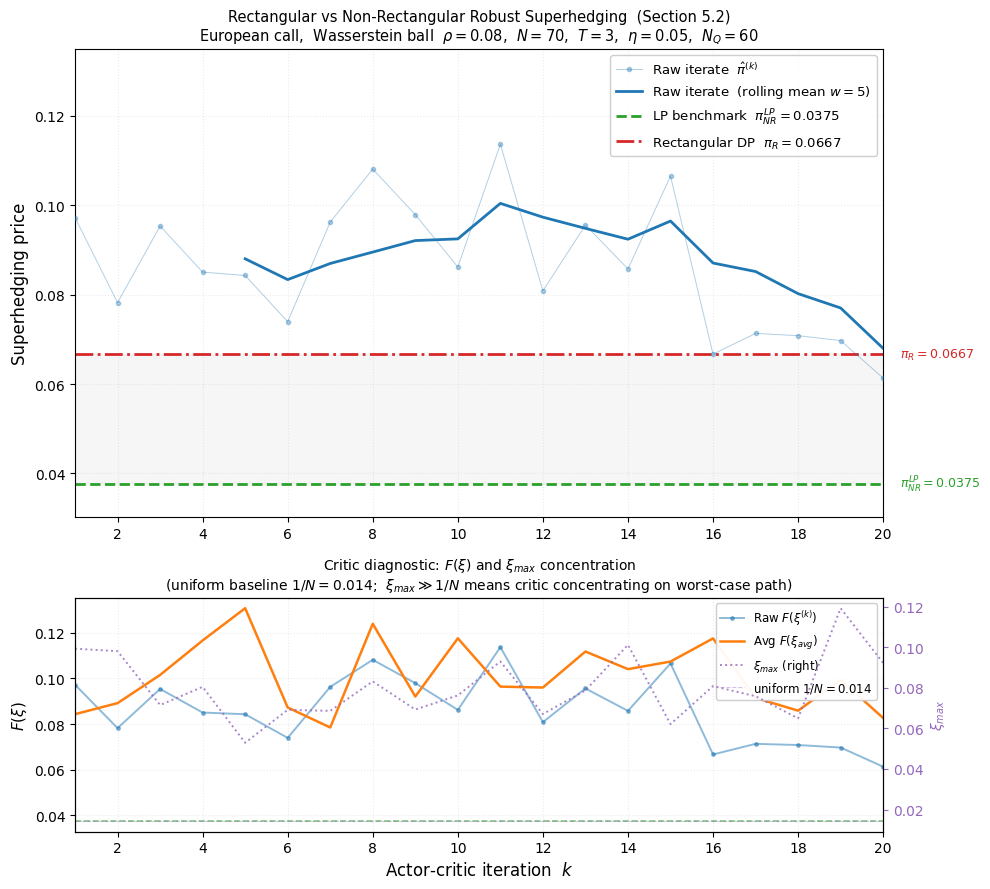

In [43]:
# ═══════════════════════════════════════════════════════════════════════════════
# PLOT  —  two panels
# ═══════════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9),
                                gridspec_kw={"height_ratios": [3, 1.5]})
fig.subplots_adjust(hspace=0.40)

iters   = np.arange(1, N_AC_ITERS + 1)
raw_arr = np.array(raw_vals)
avg_arr = np.array(avg_vals)
WIN     = max(5, N_AC_ITERS // 12)
rolling = np.convolve(raw_arr, np.ones(WIN) / WIN, mode="valid")
roll_x  = iters[WIN - 1:]
gap     = abs(rect_price - lp_price)

# ── Panel 1: convergence ─────────────────────────────────────────────────────
ax1.plot(iters, raw_arr,
         color="#1f77b4", lw=0.7, marker="o", ms=3, alpha=0.35, zorder=3,
         label=r"Raw iterate  $\hat{\pi}^{(k)}$")
ax1.plot(roll_x, rolling,
         color="#1f77b4", lw=2.0, zorder=4,
         label=rf"Raw iterate  (rolling mean $w={WIN}$)")
ax1.axhline(lp_price,   color="#2ca02c", lw=2.0, ls="--", zorder=2,
            label=rf"LP benchmark  $\pi_{{NR}}^{{LP}} = {lp_price:.4f}$")
ax1.axhline(rect_price, color="#d62728", lw=2.0, ls="-.", zorder=2,
            label=rf"Rectangular DP  $\pi_R = {rect_price:.4f}$")
ax1.axhspan(lp_price, rect_price, alpha=0.07, color="#888888", zorder=1)
ax1.annotate(rf"$\pi_R={rect_price:.4f}$",
             xy=(N_AC_ITERS + 0.4, rect_price), fontsize=9,
             color="#d62728", va="center", annotation_clip=False)
ax1.annotate(rf"$\pi_{{NR}}^{{LP}}={lp_price:.4f}$",
             xy=(N_AC_ITERS + 0.4, lp_price), fontsize=9,
             color="#2ca02c", va="center", annotation_clip=False)
ax1.set_ylabel("Superhedging price", fontsize=12)
ax1.set_title(
    "Rectangular vs Non-Rectangular Robust Superhedging  (Section 5.2)\n"
    r"European call,  Wasserstein ball  $\rho=$"
    f"{RHO},  $N={N}$,  $T={T}$,  "
    rf"$\eta={ETA_ACTOR}$,  $N_Q={N_MC_Q}$",
    fontsize=10.5)
ax1.set_xlim(1, N_AC_ITERS)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
y_lo = min(np.min(raw_arr), np.min(avg_arr), lp_price) - gap * 0.25
y_hi = max(np.max(raw_arr), np.max(avg_arr), rect_price) + gap * 0.15
ax1.set_ylim(y_lo, y_hi)
ax1.legend(fontsize=9.5, framealpha=0.95, loc="upper right")
ax1.grid(True, alpha=0.25, ls=":")

# ── Panel 2: xi_max diagnostic ───────────────────────────────────────────────
ax2b = ax2.twinx()
ax2.plot(iters, raw_arr,  color="#1f77b4", lw=1.4, marker="o", ms=2.5, alpha=0.5,
         label=r"Raw $F(\xi^{(k)})$")
ax2.plot(iters, avg_arr,  color="#ff7f0e", lw=1.8,
         label=r"Avg $F(\xi_{avg})$")
ax2.axhline(lp_price, color="#2ca02c", lw=1.2, ls="--", alpha=0.6)
ax2b.plot(iters, xi_max_hist, color="#9467bd", lw=1.4, ls=":", alpha=0.8,
          label=r"$\xi_{max}$ (right)")
ax2b.axhline(1.0 / N, color="#9467bd", lw=0.8, ls="--", alpha=0.4,
             label=f"uniform $1/N={1/N:.3f}$")
ax2b.set_ylabel(r"$\xi_{max}$", fontsize=10, color="#9467bd")
ax2b.tick_params(axis="y", colors="#9467bd")
ax2.set_xlabel("Actor-critic iteration  $k$", fontsize=12)
ax2.set_ylabel(r"$F(\xi)$", fontsize=11)
ax2.set_title(
    r"Critic diagnostic: $F(\xi)$ and $\xi_{max}$ concentration"
    "\n"
    rf"(uniform baseline $1/N = {1/N:.3f}$;"
    r"  $\xi_{max} \gg 1/N$ means critic concentrating on worst-case path)",
    fontsize=10)
ax2.set_xlim(1, N_AC_ITERS)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2,
           fontsize=8.5, framealpha=0.95, loc="upper right")
ax2.grid(True, alpha=0.25, ls=":")

fig.tight_layout()
plt.show()

## Sweeps over horizon $T$ and Wasserstein radius $\rho$

The two cells below produce the comparison plots requested:

1. $\pi_{LP}$ vs $\pi_R$ as a function of horizon $T$ (with $\rho$ fixed at the notebook value)
2. $\pi_{LP}$ vs $\pi_R$ as a function of $\rho$ (with $T$ fixed at the notebook value)

Both reuse the same path-generation and discretization grids as the main
experiment, but rebuild state per parameter combination via the self-contained
helper `solve_for_params(T_local, RHO_local)` below. No actor-critic. No
mutation of any module-level state used by the main run.

**Note on runtime.** Each call to `solve_for_params` runs one full rectangular
DP, which at the notebook defaults takes roughly $2$-$3$ minutes. Sweeping a
handful of values therefore takes 10-20 minutes. Reduce `N_PATHS_SWEEP` (or the
size of `T_VALUES` / `RHO_VALUES`) to make the sweeps faster.


In [44]:
# ═══════════════════════════════════════════════════════════════════════════════
# SWEEP HELPER  —  self-contained (T, RHO) -> (pi_LP, pi_R)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Rebuilds path data, distance matrix, and history structure for the given
# (T, RHO) pair, then solves both the non-rectangular LP benchmark and the
# rectangular DP using the SAME formulations as cells 12 and 14.
#
# Reuses notebook-level constants:  S0, MU, K_STRIKE, N_PATHS, PREC,
#                                   W_GRID, NW, A_GRID, NA.
# ─────────────────────────────────────────────────────────────────────────────

# Tunable for sweeps; defaults to the notebook value.  Smaller -> much faster.
N_PATHS_SWEEP = N_PATHS

# Same discrete shock grid as cell 6
_SHOCK_GRID = np.array([-2, -1, 0, 1, 2]) * 0.05


def _generate_paths_local(T_, rng):
    paths_ = []
    for _ in range(N_PATHS_SWEEP):
        s = [S0]
        for _t in range(T_):
            s.append(s[-1] + MU + rng.choice(_SHOCK_GRID))
        paths_.append(s)
    return np.array(paths_)


def solve_for_params(T_, RHO_, seed=0, verbose=False):
    """
    End-to-end:  build paths, distances, history -> solve LP + rect DP.
    Returns (pi_LP, pi_R).
    """
    rng = np.random.default_rng(seed)

    # ─── 1. Local data ────────────────────────────────────────────────────
    paths_   = _generate_paths_local(T_, rng)
    N_       = len(paths_)
    ds_      = np.diff(paths_, axis=1)
    payoffs_ = np.maximum(paths_[:, -1] - K_STRIKE, 0.0)
    xi_0_    = np.ones(N_) / N_
    D_       = np.array([[np.sum(np.abs(paths_[i] - paths_[j]))
                          for j in range(N_)] for i in range(N_)])

    # ─── 2. Consistent sets and unique history nodes ──────────────────────
    consistent_ = {}
    for i in range(N_):
        for t in range(T_):
            pref = tuple(np.round(paths_[i, :t + 1], PREC))
            consistent_[(i, t)] = [
                j for j in range(N_)
                if tuple(np.round(paths_[j, :t + 1], PREC)) == pref
            ]

    unique_nodes_ = {}
    for t in range(T_):
        seen = {}
        for i in range(N_):
            key = frozenset(consistent_[(i, t)])
            if key not in seen:
                seen[key] = i
        unique_nodes_[t] = [(rep_i, list(C)) for C, rep_i in seen.items()]

    # ─── 3. Local nearest-w (W_GRID is the global notebook grid) ──────────
    def nearest_w_local(w):
        return int(np.clip(np.argmin(np.abs(W_GRID - w)), 0, NW - 1))

    # ─── 4. LP benchmark (non-rectangular Wasserstein) ────────────────────
    node_map, path_nodes = {}, []
    for i in range(N_):
        row = []
        for t in range(T_):
            key = (t, tuple(np.round(paths_[i, :t + 1], PREC)))
            if key not in node_map:
                node_map[key] = len(node_map)
            row.append(node_map[key])
        path_nodes.append(row)

    x_var = cp.Variable()
    h_var = cp.Variable(len(node_map))
    cons = []
    for i in range(N_):
        wealth_i = x_var + cp.sum([
            h_var[path_nodes[i][t]] * float(ds_[i, t])
            for t in range(T_)
        ])
        cons.append(wealth_i >= payoffs_[i])
    prob_lp = cp.Problem(cp.Minimize(x_var), cons)
    prob_lp.solve(solver=cp.HIGHS)
    if prob_lp.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"LP failed: {prob_lp.status}")
    pi_LP = float(x_var.value)

    # ─── 5. Local Wasserstein-max for the DP root ─────────────────────────
    def wmax_local(v):
        Gamma = cp.Variable((N_, N_), nonneg=True)
        xi    = cp.Variable(N_, nonneg=True)
        p     = cp.Problem(
            cp.Maximize(xi @ v),
            [
                cp.sum(Gamma, axis=1) == xi,
                cp.sum(Gamma, axis=0) == xi_0_,
                cp.sum(cp.multiply(Gamma, D_)) <= RHO_,
                cp.sum(xi) == 1,
            ]
        )
        p.solve(solver=cp.HIGHS)
        val = xi.value
        if val is None:
            return xi_0_.copy()
        val = np.maximum(val, 0.0)
        return val / val.sum()

    # ─── 6. Local CC solver class (reads N_, xi_0_, D_, RHO_) ─────────────
    class _CCSolverLocal:
        def __init__(self, C):
            self.C = C
            self.v_param = cp.Parameter(len(C))
            xi    = cp.Variable(N_, nonneg=True)
            tau   = cp.Variable(nonneg=True)
            Gamma = cp.Variable((N_, N_), nonneg=True)
            self.prob = cp.Problem(
                cp.Maximize(xi[C] @ self.v_param),
                [
                    cp.sum(Gamma, axis=1) == xi,
                    cp.sum(Gamma, axis=0) == tau * xi_0_,
                    cp.sum(cp.multiply(Gamma, D_)) <= tau * RHO_,
                    cp.sum(xi[C]) == 1,
                ]
            )

        def solve(self, v_C):
            self.v_param.value = np.asarray(v_C, dtype=float)
            self.prob.solve(solver=cp.HIGHS)
            if self.prob.status not in ("optimal", "optimal_inaccurate"):
                raise RuntimeError(
                    f"CC LP failed (status={self.prob.status}, |C|={len(self.C)})"
                )
            return float(self.prob.value)

    # ─── 7. Rectangular DP (backward induction) ───────────────────────────
    V = np.zeros((N_, NW))
    for i in range(N_):
        for w_idx, w in enumerate(W_GRID):
            V[i, w_idx] = max(payoffs_[i] - w, 0.0)

    for t in reversed(range(T_)):
        V_new      = np.zeros((N_, NW))
        node_cache = {}

        for rep_i, C in unique_nodes_[t]:
            cc       = _CCSolverLocal(C)
            cc_cache = {}
            best_a_val = np.full(NW, np.inf)

            for w_idx, w in enumerate(W_GRID):
                for a in A_GRID:
                    v_idx = tuple(
                        nearest_w_local(w + a * float(ds_[j, t]))
                        for j in C
                    )
                    if v_idx not in cc_cache:
                        v_C = np.array([V[j, v_idx[k]]
                                        for k, j in enumerate(C)])
                        cc_cache[v_idx] = cc.solve(v_C)
                    cc_val = cc_cache[v_idx]
                    if cc_val < best_a_val[w_idx]:
                        best_a_val[w_idx] = cc_val

            node_cache[frozenset(C)] = best_a_val

        for i in range(N_):
            V_new[i, :] = node_cache[frozenset(consistent_[(i, t)])]
        V = V_new

        if verbose:
            print(f"      t={t} done   ({len(unique_nodes_[t])} nodes)")

    w0    = nearest_w_local(0.0)
    vals  = V[:, w0]
    xi_wc = wmax_local(vals)
    pi_R  = float(xi_wc @ vals)

    return pi_LP, pi_R


### Plot 1 — prices vs horizon $T$

$\rho$ is held at the notebook default. For each $T \in $ `T_VALUES` we
generate a fresh sample of $N$ paths, solve both LPs, and plot the two prices.
The non-rectangular LP price is a lower bound on the rectangular DP price by
Proposition 1, so the green curve should sit weakly below the red.

**Note on $T=1$.** The rectangular DP runs on the discretized
$(W_{\text{grid}}, A_{\text{grid}})$ inherited from the main experiment,
whose wealth spacing is $\approx 0.078$ — coarse relative to the call payoff
range. At $T=1$ there is only one wealth update and no further hedging to
absorb grid-snapping error, so $\pi_R$ picks up a noticeable downward bias.
For $T\ge 2$ the bias is smaller and the theoretical ordering
$\pi_{LP}\le\pi_R$ holds. `T_VALUES` therefore starts at 2 by default.


In [45]:
# ═══════════════════════════════════════════════════════════════════════════════
# SWEEP 1:  pi_LP and pi_R vs horizon T   (rho fixed at notebook value)
# ═══════════════════════════════════════════════════════════════════════════════

# T=1 omitted: the existing W_GRID is too coarse for the single-step DP to
# reflect true shortfalls (see the note above). Extend at your own runtime risk:
# T=4 is roughly 10+ minutes per call.
T_VALUES = [2, 3,4,5]

t0 = time.time()
lp_by_T, rect_by_T = [], []
for T_ in T_VALUES:
    tt = time.time()
    pi_LP, pi_R = solve_for_params(T_, RHO, seed=0)
    lp_by_T.append(pi_LP)
    rect_by_T.append(pi_R)
    print(f"  T={T_}:  pi_LP = {pi_LP:.5f}   pi_R = {pi_R:.5f}   "
          f"gap = {pi_R - pi_LP:.5f}   ({time.time()-tt:.1f}s)")
print(f"  total: {time.time()-t0:.1f}s")

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T_VALUES, lp_by_T,   "o-", color="#2ca02c", lw=2, ms=7,
        label=r"Non-rectangular LP  $\pi_{NR}^{LP}$")
ax.plot(T_VALUES, rect_by_T, "s-", color="#d62728", lw=2, ms=7,
        label=r"Rectangular DP  $\pi_R$")
ax.fill_between(T_VALUES, lp_by_T, rect_by_T,
                color="#888888", alpha=0.12,
                label=r"gap  $\pi_R - \pi_{NR}^{LP}$")
ax.set_xlabel("Horizon  $T$", fontsize=12)
ax.set_ylabel("Superhedging price", fontsize=12)
ax.set_title(
    "Robust superhedging prices vs horizon\n"
    rf"European call,  Wasserstein ball  $\rho={RHO}$,  $N={N_PATHS_SWEEP}$",
    fontsize=11)
ax.set_xticks(T_VALUES)
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.show()


  T=2:  pi_LP = 0.03040   pi_R = 0.06667   gap = 0.03627   (8.9s)
  T=3:  pi_LP = 0.04288   pi_R = 0.06900   gap = 0.02612   (26.2s)


RuntimeError: LP failed: unbounded

### Plot 2 — prices vs Wasserstein radius $\rho$

$T$ is held at the notebook default. As $\rho$ grows, both prices increase
(larger ambiguity set $\Rightarrow$ stricter superhedging requirement). The
non-rectangular LP price is a lower bound on the rectangular DP price by
Proposition 1.

**Note on the small-$\rho$ regime.** The rectangular DP runs on a discretized
$(W_{\text{grid}}, A_{\text{grid}})$ state-action space, which introduces a
small downward bias in $\pi_R$ relative to the LP benchmark (the LP benchmark
is exact in path space, with no wealth grid). For $\rho$ large enough that the
adversarial inflation dominates the discretization error, the theoretical
ordering $\pi_{LP} \le \pi_R$ holds; for very small $\rho$ this can be
swamped by the grid bias. This is a property of the existing DP, not of the
sweep itself. To make the small-$\rho$ end clean you would need a finer
$W_{\text{grid}}$.


  rho=0.040:  pi_LP = 0.04288   pi_R = 0.05651   gap = 0.01363   (24.5s)
  rho=0.080:  pi_LP = 0.04288   pi_R = 0.06900   gap = 0.02612   (26.1s)
  rho=0.120:  pi_LP = 0.04288   pi_R = 0.07285   gap = 0.02997   (27.1s)
  rho=0.160:  pi_LP = 0.04288   pi_R = 0.07448   gap = 0.03160   (26.5s)
  rho=0.200:  pi_LP = 0.04288   pi_R = 0.07567   gap = 0.03279   (26.5s)
  total: 130.5s


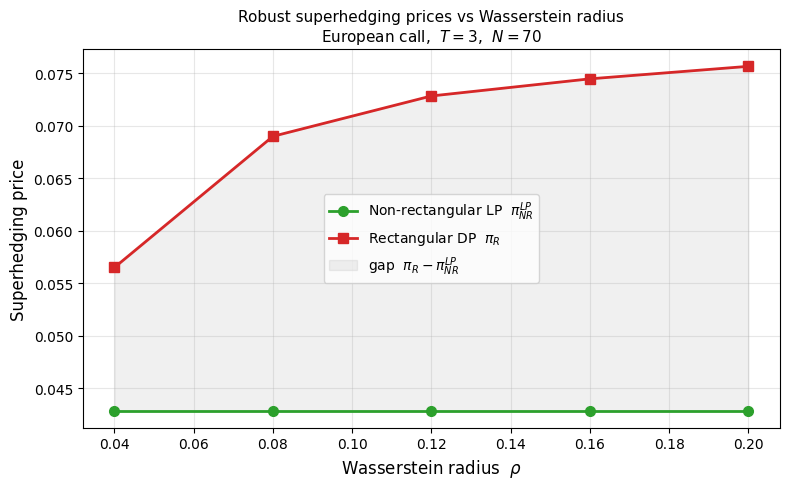

In [46]:
# ═══════════════════════════════════════════════════════════════════════════════
# SWEEP 2:  pi_LP and pi_R vs Wasserstein radius rho   (T fixed at notebook value)
# ═══════════════════════════════════════════════════════════════════════════════

# rho=0 omitted: the rect DP picks up a grid-discretisation artifact at zero
# ambiguity that is unrelated to the rectangularization gap (see the note above).
RHO_VALUES = [0.04, 0.08, 0.12, 0.16, 0.20]

t0 = time.time()
lp_by_R, rect_by_R = [], []
for rho_ in RHO_VALUES:
    tt = time.time()
    pi_LP, pi_R = solve_for_params(T, rho_, seed=0)
    lp_by_R.append(pi_LP)
    rect_by_R.append(pi_R)
    print(f"  rho={rho_:.3f}:  pi_LP = {pi_LP:.5f}   pi_R = {pi_R:.5f}   "
          f"gap = {pi_R - pi_LP:.5f}   ({time.time()-tt:.1f}s)")
print(f"  total: {time.time()-t0:.1f}s")

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(RHO_VALUES, lp_by_R,   "o-", color="#2ca02c", lw=2, ms=7,
        label=r"Non-rectangular LP  $\pi_{NR}^{LP}$")
ax.plot(RHO_VALUES, rect_by_R, "s-", color="#d62728", lw=2, ms=7,
        label=r"Rectangular DP  $\pi_R$")
ax.fill_between(RHO_VALUES, lp_by_R, rect_by_R,
                color="#888888", alpha=0.12,
                label=r"gap  $\pi_R - \pi_{NR}^{LP}$")
ax.set_xlabel(r"Wasserstein radius  $\rho$", fontsize=12)
ax.set_ylabel("Superhedging price", fontsize=12)
ax.set_title(
    "Robust superhedging prices vs Wasserstein radius\n"
    rf"European call,  $T={T}$,  $N={N_PATHS_SWEEP}$",
    fontsize=11)
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.show()
